# Surrogate model evaluation

Runs the exact same offline accuracy evaluation as `evaluator.py`'s `evaluate_surrogate()` -- the same
function used by the `evaluate_surrogate` CLI command -- on every checkpoint currently trained, and
renders the results inline instead of writing JSON + PNG files to disk. Nothing here reimplements the
metrics: every number and every plot below comes from calling `evaluate_surrogate()` itself.

When a shared `failure_classifier_*.pt` checkpoint is also found (trained alongside the surrogate
ensemble by `trainer.py`), its precision/recall/F1 at separating true all-particles-lost samples, plus
a "gated" score-metrics block, are reported too -- see section 2 and
[`visualize_surrogate_model.ipynb` section 6](visualize_surrogate_model.ipynb) for why that classifier
exists.

This notebook is read-only: it loads existing checkpoints/datasets and evaluates them in memory, it
does not train, fine-tune, or write anything back to `trained_models/`.

**Related notebooks:**
- [`visualize_surrogate_model.ipynb`](visualize_surrogate_model.ipynb) -- the `ModularMLP` architecture
  being evaluated here (layers, input/output contract), and the `FailureClassifier` (section 6).
- [`env/dataset/visualize_dataset.ipynb`](../../../dataset/visualize_dataset.ipynb) -- the `BeamDataset`
  format the evaluation dataset below is loaded from.

In [1]:
from pathlib import Path
import sys
import tempfile

import numpy as np
import torch
from IPython.display import Image, Markdown, display

WORKING_DIR = Path.cwd().resolve()
if (WORKING_DIR / 'beam_optimization').is_dir():
    REPO_ROOT = WORKING_DIR
else:
    PROJECT_ROOT = WORKING_DIR
    while PROJECT_ROOT.name != 'beam_optimization' and PROJECT_ROOT.parent != PROJECT_ROOT:
        PROJECT_ROOT = PROJECT_ROOT.parent
    REPO_ROOT = PROJECT_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from beam_optimization.config.paths import DEFAULT_BASE_SURROGATE_DIR, DEFAULT_UPDATED_SURROGATE_DIR
from beam_optimization.env.dataset import BeamDataset
from beam_optimization.env.surrogate_env.surrogate.model.modular_mlp import ModularMLP
from beam_optimization.env.surrogate_env.surrogate.model.failure_classifier import FailureClassifier
from beam_optimization.env.surrogate_env.surrogate.model.trainer import compute_normalization_metadata
from beam_optimization.env.surrogate_env.surrogate.model.evaluator import (
    evaluate_surrogate, _default_test_dataset_path,
)


def fmt(value):
    if value is None:
        return 'n/a'
    return f'{float(value):.6g}'


def table(headers, rows):
    lines = ['| ' + ' | '.join(headers) + ' |', '| ' + ' | '.join(['---'] * len(headers)) + ' |']
    lines.extend('| ' + ' | '.join(str(cell) for cell in row) + ' |' for row in rows)
    return '\n'.join(lines)

## 1. Checkpoints and evaluation dataset

`evaluate_surrogate_folder()` (what the `evaluate_surrogate` CLI command calls) evaluates every
`surrogate_*.pt` file in one directory. This cell reuses the exact same discovery order the CLI's
default arguments use: `trained_models/base/` first (the clean offline-trained ensemble), falling back
to `trained_models/updated/` (the online-fine-tuned working ensemble), and the same
`_default_test_dataset_path()` helper `evaluator.py` itself uses to pick the newest dataset that
actually has a completed `dataset_test.pt` split (not just the newest numbered folder, which may still
be mid-build and lack one).

In [2]:
base_ckpts = sorted(DEFAULT_BASE_SURROGATE_DIR.glob('surrogate_*.pt')) if DEFAULT_BASE_SURROGATE_DIR.exists() else []
updated_ckpts = sorted(DEFAULT_UPDATED_SURROGATE_DIR.glob('surrogate_*.pt')) if DEFAULT_UPDATED_SURROGATE_DIR.exists() else []

if base_ckpts:
    checkpoint_paths, checkpoint_source = base_ckpts, str(DEFAULT_BASE_SURROGATE_DIR)
elif updated_ckpts:
    checkpoint_paths, checkpoint_source = updated_ckpts, str(DEFAULT_UPDATED_SURROGATE_DIR)
else:
    checkpoint_paths, checkpoint_source = [], None

DATASET_PATH = _default_test_dataset_path()
dataset = BeamDataset.load(DATASET_PATH)

print(f'base      ({DEFAULT_BASE_SURROGATE_DIR}): {len(base_ckpts)} checkpoint(s)')
print(f'updated   ({DEFAULT_UPDATED_SURROGATE_DIR}): {len(updated_ckpts)} checkpoint(s)')
print(f'evaluating {len(checkpoint_paths)} checkpoint(s) from: {checkpoint_source}')

models = []  # list of (name, model)
if checkpoint_paths:
    for path in checkpoint_paths:
        models.append((path.name, ModularMLP.load(str(path))))
else:
    norm_stats = compute_normalization_metadata(dataset)
    models.append(('untrained (demo)', ModularMLP(norm_stats=norm_stats)))
    print('\nNo trained checkpoint found in either directory yet (train one with the `train_surrogate` '
          'command). Evaluating a freshly-initialized ModularMLP instead so the rest of this notebook '
          'still runs end to end -- every metric and plot below will reflect random weights, not real '
          'surrogate accuracy, until a real checkpoint exists.')

# The shared FailureClassifier (trainer.py trains one per run, independent of ensemble size) lives
# alongside the surrogate_*.pt checkpoints, named failure_classifier_<dataset>.pt. Optional: when
# missing, the rest of the notebook simply reports the regression metrics without the classifier
# section, exactly like evaluate_surrogate() does when classifier=None.
classifier_ckpts = (
    sorted(Path(checkpoint_source).glob('failure_classifier_*.pt')) if checkpoint_source else []
)
if classifier_ckpts:
    classifier = FailureClassifier.load(str(classifier_ckpts[0]))
    classifier.eval()
    print(f'\nLoaded shared failure classifier: {classifier_ckpts[0].name}')
else:
    classifier = None
    print('\nNo failure_classifier_*.pt found next to the surrogate checkpoints -- '
          'classifier_metrics/score_metrics_gated will be skipped below.')

[BeamDataset] 2,000 samples loaded from /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/dataset/013/dataset_test.pt
base      (/mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/surrogate_env/surrogate/trained_models/base): 0 checkpoint(s)
updated   (/mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/surrogate_env/surrogate/trained_models/updated): 0 checkpoint(s)
evaluating 0 checkpoint(s) from: None

No trained checkpoint found in either directory yet (train one with the `train_surrogate` command). Evaluating a freshly-initialized ModularMLP instead so the rest of this notebook still runs end to end -- every metric and plot below will reflect random weights, not real surrogate accuracy, until a real checkpoint exists.

No failure_classifier_*.pt found next to the surrogate checkpoints -- classifier_metrics/score_metrics_gated will be skipped below.


## 2. Running `evaluate_surrogate()`

Calls the real function once per model, exactly as `evaluate_surrogate_folder()` does internally:
batched forward passes over the whole dataset, per-(stage, feature) SSE/SAE accumulated in native
physical units, then reduced to MSE/MAE/RMSE per stage, per feature, and overall, plus final-score
metrics (MAE, RMSE, bias, Pearson r, R²) via the project's real `score_tensor()`. `plots_dir` points at
a throwaway temporary directory -- the same plotting code `evaluator.py` uses to save PNGs to disk is
reused untouched, the files are just displayed inline here and discarded afterward instead of being
kept under `results/`.

When a shared `failure_classifier_*.pt` was found in section 1, it is also passed in: `evaluate_surrogate()`
then additionally reports how well it separates true all-particles-lost samples from the rest
(`classifier_metrics` -- precision/recall/F1/confusion matrix) and a second "gated" score-metrics block
computed as if the classifier's override (see `surrogate_simulator.run_surrogate_forward()`) had been
applied to every prediction (`score_metrics_gated`). This never changes the plain `score_metrics` above
it -- it is purely an additional diagnostic, see
[`visualize_surrogate_model.ipynb` section 6](visualize_surrogate_model.ipynb#6.-FailureClassifier:-gating-the-all-particles-lost-cliff)
for why the classifier exists and how it's trained.

In [3]:
all_results = {}
with tempfile.TemporaryDirectory() as tmp:
    tmp_dir = Path(tmp)
    for name, model in models:
        all_results[name] = evaluate_surrogate(
            model, dataset, plots_dir=tmp_dir, plot_prefix=Path(name).stem, classifier=classifier,
        )
        # Plot PNGs must be read into memory now, inside the `with` block, before the
        # temporary directory (and the files in it) are deleted on exit.
        for plot_name, plot_path in all_results[name]['plots'].items():
            all_results[name]['plots'][plot_name] = Path(plot_path).read_bytes()

print(f'Evaluated {len(all_results)} model(s) on {len(dataset):,} samples from {DATASET_PATH.name}.')

Evaluated 1 model(s) on 2,000 samples from dataset_test.pt.


## 3. Report, per model

### `untrained (demo)`

**Summary**

| Metric | Value |
| --- | --- |
| Samples | 2,000 |
| MSE (all stages) | 180.419 |
| RMSE (all stages) | 13.432 |
| MSE (final stage) | 12.6306 |
| RMSE (final stage) | 3.55396 |

**Final-score metrics** (`score_tensor()` on the final predicted vs. true beam state)

| Metric | Value |
| --- | --- |
| MAE | 130.068 |
| RMSE | 347.098 |
| Bias | 124.048 |
| Pearson r | 0.00997436 |
| R² | -0.146403 |
| True mean / std | -113.445 / 324.178 |
| Predicted mean / std | 10.603 / 0.363471 |

**Per-feature errors** (native units, averaged over all stages vs. final stage only)

| Feature | RMSE all stages | MAE all stages | RMSE final stage | MAE final stage |
| --- | --- | --- | --- | --- |
| `npart_ratio` | 0.146199 | 0.0601671 | 0.120643 | 0.101432 |
| `x0` | 9.61458 | 4.25146 | 2.66121 | 2.06273 |
| `y0` | 8.80638 | 3.08975 | 3.25258 | 2.60807 |
| `SizeX` | 9.24405 | 3.84954 | 1.77151 | 1.10303 |
| `SizeY` | 8.08407 | 1.71826 | 1.5931 | 1.42353 |
| `ex` | 4.00512 | 0.260381 | 0.0156082 | 0.0127583 |
| `ey` | 0.511594 | 0.0704615 | 0.0209297 | 0.0155888 |
| `x'0` | 34.5147 | 4.76065 | 6.47813 | 5.24028 |
| `y'0` | 9.76642 | 4.58777 | 6.9539 | 5.62138 |

**Per-stage RMSE** (TraceWin marker -> RMSE, native units, summed over all 9 features)

| Stage marker | RMSE |
| --- | --- |
| 2 | 0.00934267 |
| 29 | 0.039112 |
| 108 | 0.800546 |
| 151 | 1.29132 |
| 162 | 3.35332 |
| 195 | 3.61322 |
| 197 | 43.2803 |
| 203 | 9.03032 |
| 205 | 10.2828 |
| 225 | 4.86822 |
| 261 | 6.4512 |
| 332 | 3.55396 |

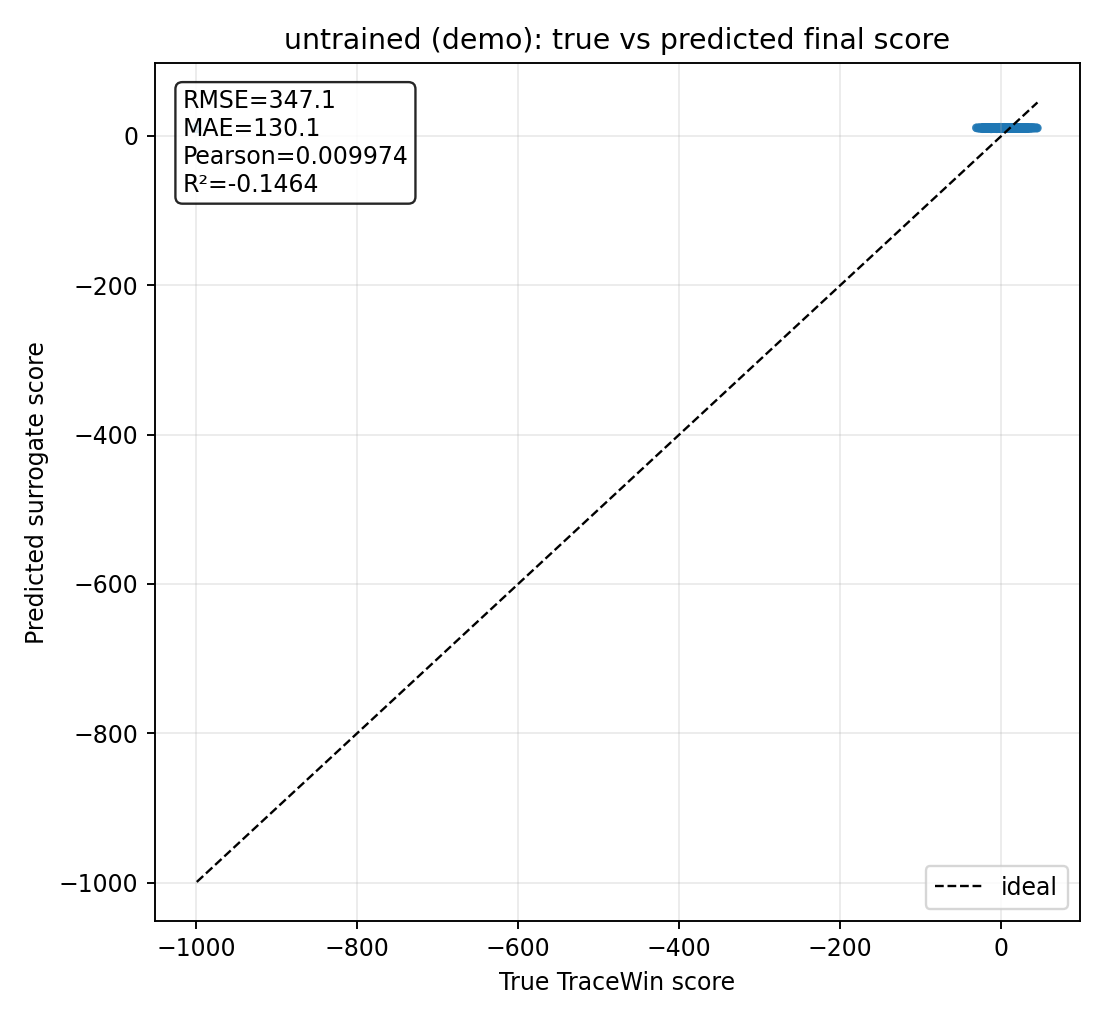

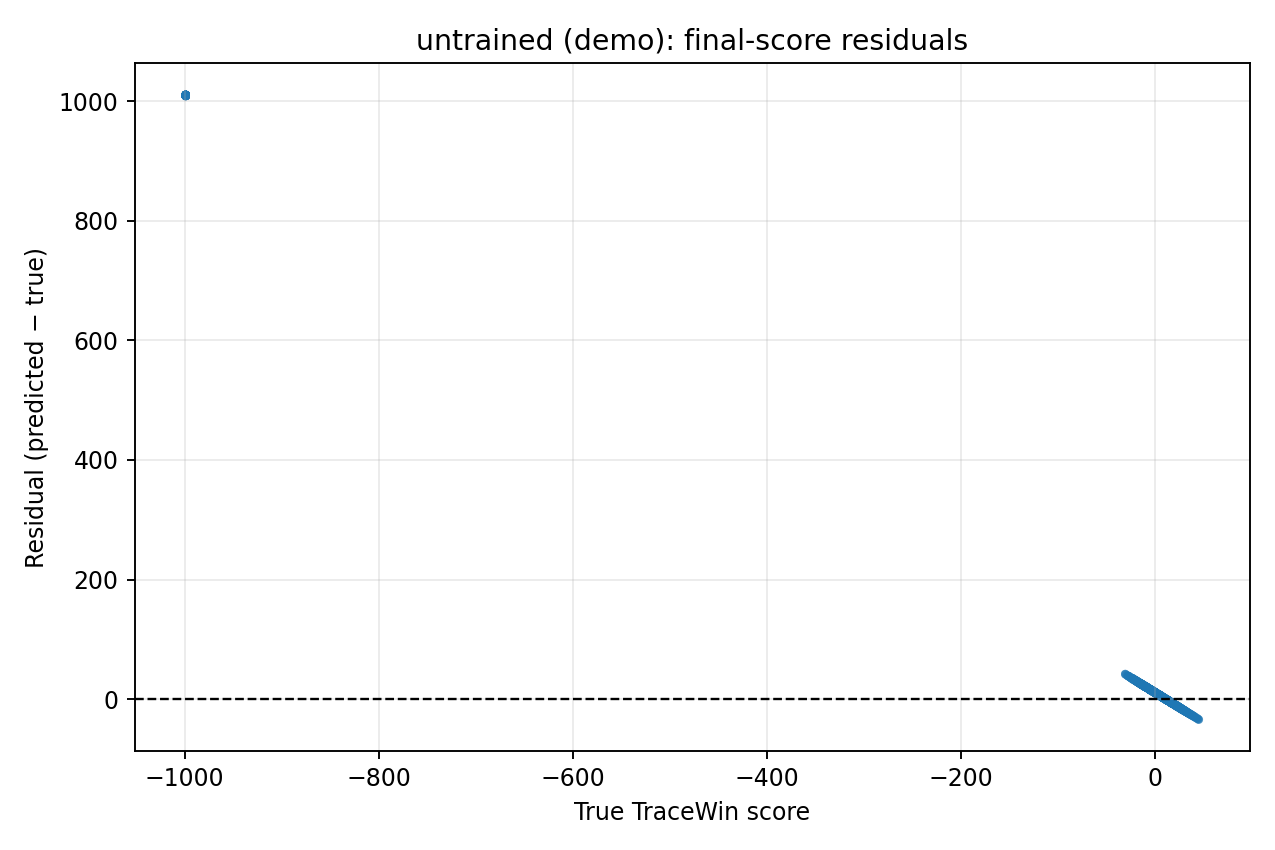

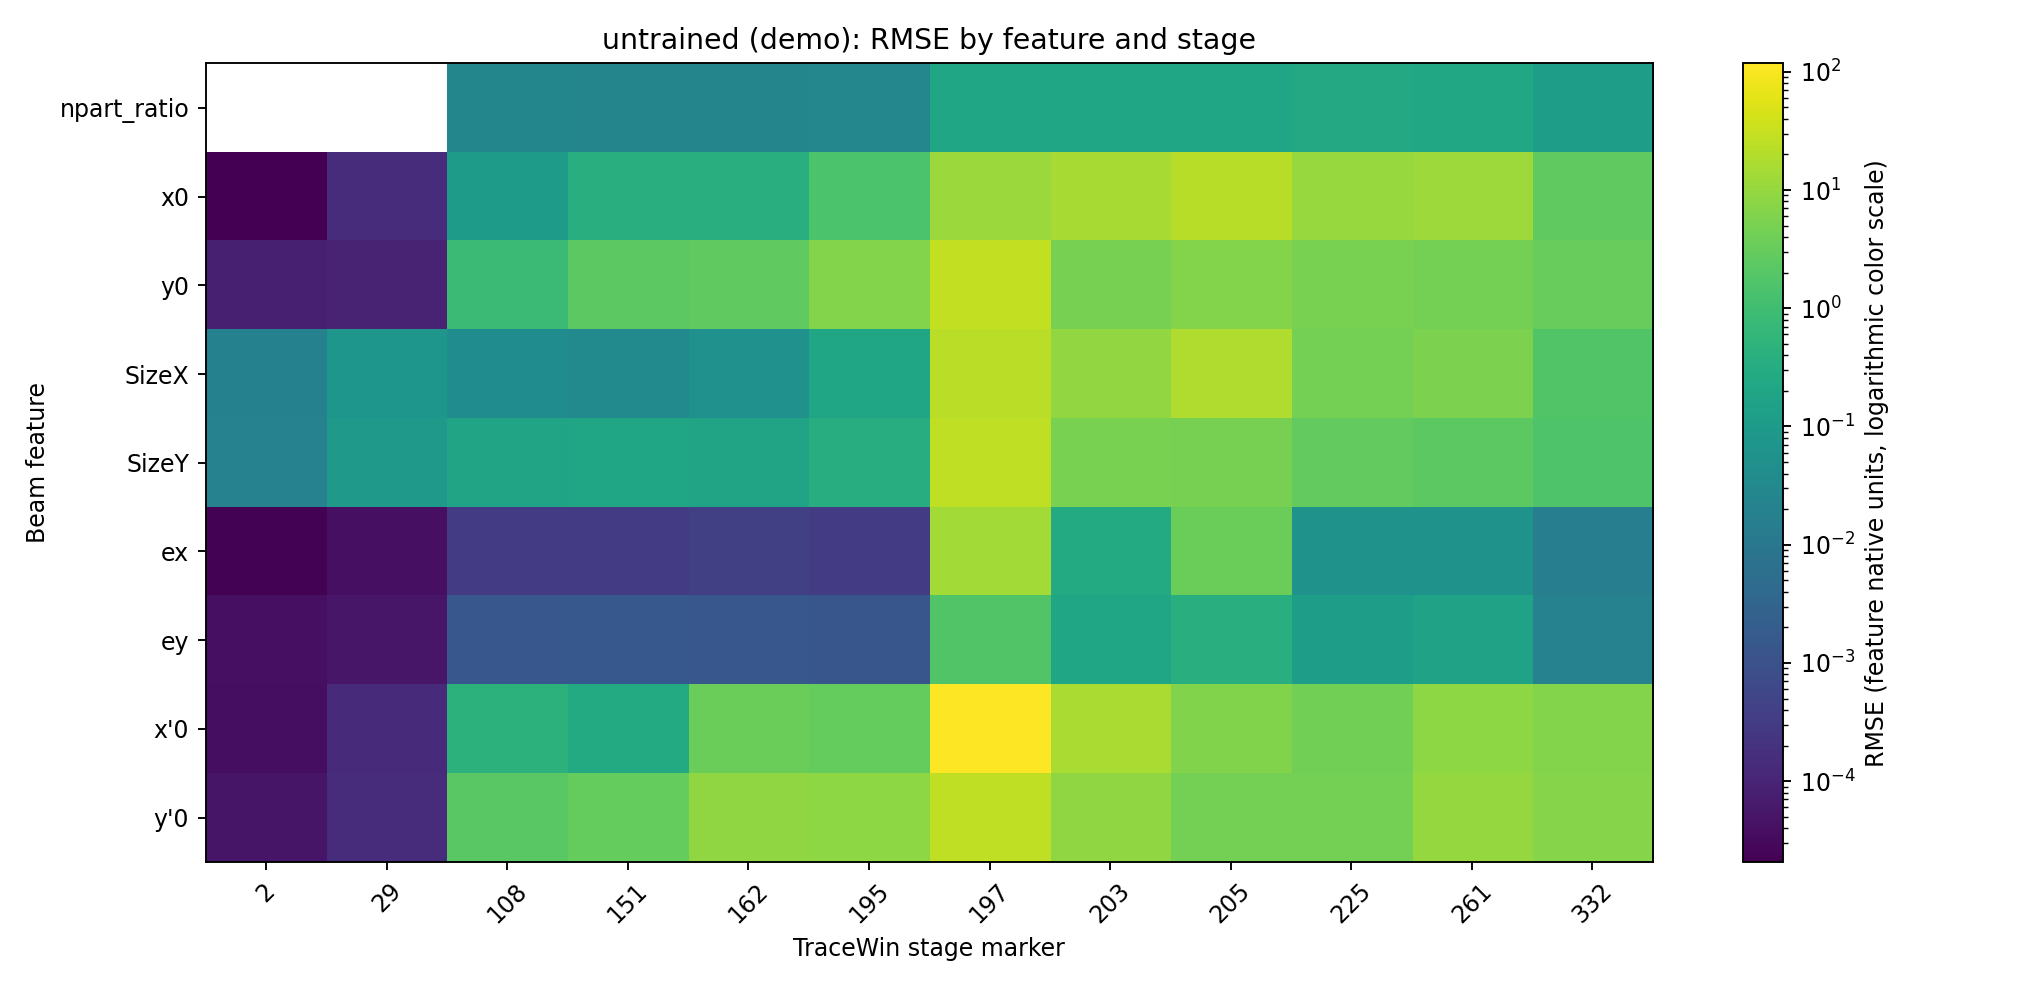

In [4]:
for name, metrics in all_results.items():
    score = metrics['score_metrics']
    summary_rows = [
        ['Samples', f"{metrics['n_samples']:,}"],
        ['MSE (all stages)', fmt(metrics['mse_all'])],
        ['RMSE (all stages)', fmt(metrics['rmse_all'])],
        ['MSE (final stage)', fmt(metrics['mse_final_stage'])],
        ['RMSE (final stage)', fmt(metrics['rmse_final_stage'])],
    ]
    score_rows = [
        ['MAE', fmt(score['mae'])], ['RMSE', fmt(score['rmse'])], ['Bias', fmt(score['bias'])],
        ['Pearson r', fmt(score['pearson_correlation'])], ['R²', fmt(score['r2'])],
        ['True mean / std', f"{fmt(score['true_mean'])} / {fmt(score['true_std'])}"],
        ['Predicted mean / std', f"{fmt(score['predicted_mean'])} / {fmt(score['predicted_std'])}"],
    ]
    feature_rows = [
        [
            f"`{feature}`", fmt(values['rmse_all_stages']), fmt(values['mae_all_stages']),
            fmt(values['rmse_final_stage']), fmt(values['mae_final_stage']),
        ]
        for feature, values in metrics['feature_metrics'].items()
    ]
    stage_rows = [
        [marker, fmt(rmse)] for marker, rmse in zip(metrics['stage_markers'], metrics['rmse_per_stage'])
    ]

    sections = [
        f'### `{name}`',
        '**Summary**',
        table(['Metric', 'Value'], summary_rows),
        '**Final-score metrics** (`score_tensor()` on the final predicted vs. true beam state)',
        table(['Metric', 'Value'], score_rows),
        '**Per-feature errors** (native units, averaged over all stages vs. final stage only)',
        table(['Feature', 'RMSE all stages', 'MAE all stages', 'RMSE final stage', 'MAE final stage'], feature_rows),
        '**Per-stage RMSE** (TraceWin marker -> RMSE, native units, summed over all 9 features)',
        table(['Stage marker', 'RMSE'], stage_rows),
    ]

    if metrics.get('classifier_metrics'):
        cm = metrics['classifier_metrics']
        gated = metrics['score_metrics_gated']
        cm_rows = [
            ['Precision', fmt(cm['precision'])], ['Recall', fmt(cm['recall'])],
            ['F1', fmt(cm['f1'])], ['Accuracy', fmt(cm['accuracy'])],
            ['True failures / samples', f"{cm['n_true_failures']:,} / {cm['n_samples']:,}"],
            ['Confusion matrix (tp/fp/fn/tn)',
             f"{cm['confusion_matrix']['tp']:.0f} / {cm['confusion_matrix']['fp']:.0f} / "
             f"{cm['confusion_matrix']['fn']:.0f} / {cm['confusion_matrix']['tn']:.0f}"],
        ]
        gated_rows = [
            ['MAE', fmt(gated['mae'])], ['RMSE', fmt(gated['rmse'])], ['Bias', fmt(gated['bias'])],
            ['Pearson r', fmt(gated['pearson_correlation'])], ['R²', fmt(gated['r2'])],
        ]
        sections += [
            '**Failure classifier metrics** (all-particles-lost, threshold={:.2g}) -- '
            'recall on the failure class matters most: a false negative here means a real '
            'all-particles-lost sample is still scored by the (unreliable near the cliff) '
            'regressor.'.format(cm['threshold']),
            table(['Metric', 'Value'], cm_rows),
            '**Final-score metrics with the classifier gate applied** (compare against the plain '
            '"Final-score metrics" table above -- same true scores, predictions overridden to '
            'ERROR_SCORE wherever the classifier fires)',
            table(['Metric', 'Value'], gated_rows),
        ]

    display(Markdown('\n\n'.join(sections)))

    for plot_name, plot_bytes in metrics['plots'].items():
        display(Image(data=plot_bytes))

## 4. Where this fits in the pipeline

- This notebook is the interactive, always-available counterpart to running
  `python -m beam_optimization.env.surrogate_env.surrogate.model.evaluator --model-dir <dir> --dataset <path>`
  directly -- same `evaluate_surrogate()` call, same numbers, just rendered here instead of written to
  `results/benchmark/surrogate_eval.json` and standalone PNGs.
- See [`visualize_surrogate_model.ipynb`](visualize_surrogate_model.ipynb) for what the model being
  evaluated actually looks like (layers, parameters, forward pass), and `trainer.py` for how a real
  checkpoint gets produced in the first place (`train_surrogate` command).
- If section 1 above evaluated an `'untrained (demo)'` model, none of the numbers or plots in this
  notebook reflect real surrogate accuracy -- re-run the notebook once a checkpoint exists under
  `trained_models/base/` or `trained_models/updated/`.